# Taxonomy exploration: R1-refined → R2 → R3

Aggregated stats and per-task visualization of the hierarchical taxonomies
built across 11 tasks × 3 specificity buckets (general / specific / hyper_specific).

Inputs come from `outputs/hierarchy/` and are produced by:
- `scripts/build_hierarchy.py`             (R1)
- `scripts/refine_parent.py`               (R1-refined)
- `scripts/meta_merge.py`                  (R2, R3)

This notebook covers Phase 1 of analyses #23–33: shape, compression,
coverage, and per-task concept inventory. Phase 2+ (diffuseness, thickness,
provenance, cross-task overlap) are stubbed at the bottom.

In [1]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/Users/spangher/Projects/stanford-research/norm-research")
HIER = ROOT / "outputs" / "hierarchy"

TASKS = [
    "code-review", "creative-writing", "grant-funding", "humor",
    "legal-outcome-prediction", "math-stackexchange", "news-homepages",
    "notice-and-comment", "patents", "peer-review", "press-releases",
]
BUCKETS = ["general", "specific", "hyper_specific"]

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 160)

## 1. Load all R1-refined / R2 / R3 outputs into per-cell summary frame

A "cell" = (task, bucket). Some buckets have no data (creative-writing only ran
general). R3 is skipped by `meta_merge.py` when R2 is too sparse to merge —
those rows have R3 fields NaN.

In [3]:
def _load_cell(task, bucket):
    cell = f"{task}_{bucket}"
    r1 = HIER / f"{cell}_r1_refined.json"
    if not r1.exists() and cell == "creative-writing_general":
        # cw/general used a different file name in early pipeline
        r1 = HIER / "creative-writing_general_r1_refined.json"
    r2 = HIER / f"{cell}_r2_expanded.json"
    r3 = HIER / f"{cell}_r3_expanded.json"
    stranded = HIER / f"{cell}_r1_refined_stranded.json"

    if not r1.exists():
        return None

    d1 = json.loads(r1.read_text())
    parents = d1.get("parented_trees", [])
    n_p1 = len(parents)
    n_c1 = sum(len(p.get("children", [])) for p in parents)
    n_leaves_r1 = sum(
        sum(c.get("size", len(c.get("rubrics", []))) for c in p.get("children", []))
        for p in parents
    )

    row = {
        "task": task,
        "bucket": bucket,
        "r1_parents": n_p1,
        "r1_children": n_c1,
        "r1_leaves": n_leaves_r1,
        "r1_avg_children_per_parent": n_c1 / max(1, n_p1),
    }

    if stranded.exists():
        sd = json.loads(stranded.read_text())
        row["n_stranded_children"] = sd.get("n_stranded", 0)

    if r2.exists():
        d2 = json.loads(r2.read_text())
        merged = d2.get("merged_groups", [])
        grand  = d2.get("grandparents", [])
        row.update({
            "r2_merged_groups": len(merged),
            "r2_grandparents": len(grand),
            "r2_leaves_in_merged": sum(m.get("total_leaf_rubrics", 0) for m in merged),
            "r2_leaves_in_grandparents": sum(g.get("total_leaf_rubrics", 0) for g in grand),
            "r2_merge_rate": len(merged) / max(1, n_p1),
            "r2_gp_rate": len(grand) / max(1, n_p1),
        })

    if r3.exists():
        d3 = json.loads(r3.read_text())
        row.update({
            "r3_merged_groups": len(d3.get("merged_groups", [])),
            "r3_grandparents": len(d3.get("grandparents", [])),
        })

    return row


cells = []
for task in TASKS:
    for bucket in BUCKETS:
        row = _load_cell(task, bucket)
        if row is not None:
            cells.append(row)

cells_df = pd.DataFrame(cells)
print(f"loaded {len(cells_df)} cells")
print()
print(cells_df[["task", "bucket", "r1_parents", "r1_leaves", "r2_merged_groups", "r2_grandparents", "r3_merged_groups", "r3_grandparents"]].to_string(index=False))

loaded 31 cells

                    task         bucket  r1_parents  r1_leaves  r2_merged_groups  r2_grandparents  r3_merged_groups  r3_grandparents
             code-review        general         589       3055               133               84              32.0             23.0
             code-review       specific        2678      10261               224              440              27.0             36.0
             code-review hyper_specific         246       1771                39               51               0.0             13.0
        creative-writing        general        1478       6428               371              214              70.0             42.0
           grant-funding        general         228       1628                91               49              16.0             17.0
           grant-funding       specific         224       1661                63               37               3.0             14.0
           grant-funding hyper_specific          44 

## 2. Compression rates by specificity bucket

Hypothesis (confirmed): more specific buckets see less duplicate-collapsing
(lower merge_rate). Grandparent rate stays similar or rises — even when items
don't merge as duplicates, they still cluster under shared parents.

In [4]:
print("Average compression metrics by bucket:")
agg = cells_df.groupby("bucket").agg(
    n_cells=("task", "size"),
    avg_merge_rate=("r2_merge_rate", "mean"),
    avg_gp_rate=("r2_gp_rate", "mean"),
).round(3)
agg = agg.loc[BUCKETS]
print(agg)

Average compression metrics by bucket:
                n_cells  avg_merge_rate  avg_gp_rate
bucket                                              
general              11           0.283        0.190
specific             10           0.189        0.164
hyper_specific       10           0.120        0.287


In [6]:
pivot_merge = cells_df.pivot(index="task", columns="bucket", values="r2_merge_rate")[BUCKETS]
pivot_merge_pct = (pivot_merge * 100).round(0).astype("Int64")
print("\nMerge rate (%) per task × bucket:")
pivot_merge_pct


Merge rate (%) per task × bucket:


bucket,general,specific,hyper_specific
task,,,
code-review,23,8,16
creative-writing,25,<NA>,<NA>
grant-funding,40,28,7
humor,25,15,5
legal-outcome-prediction,33,13,0
math-stackexchange,28,12,15
news-homepages,24,25,14
notice-and-comment,22,11,2
patents,25,23,35


## 3. Distribution of merged_group sizes — per task (general bucket)

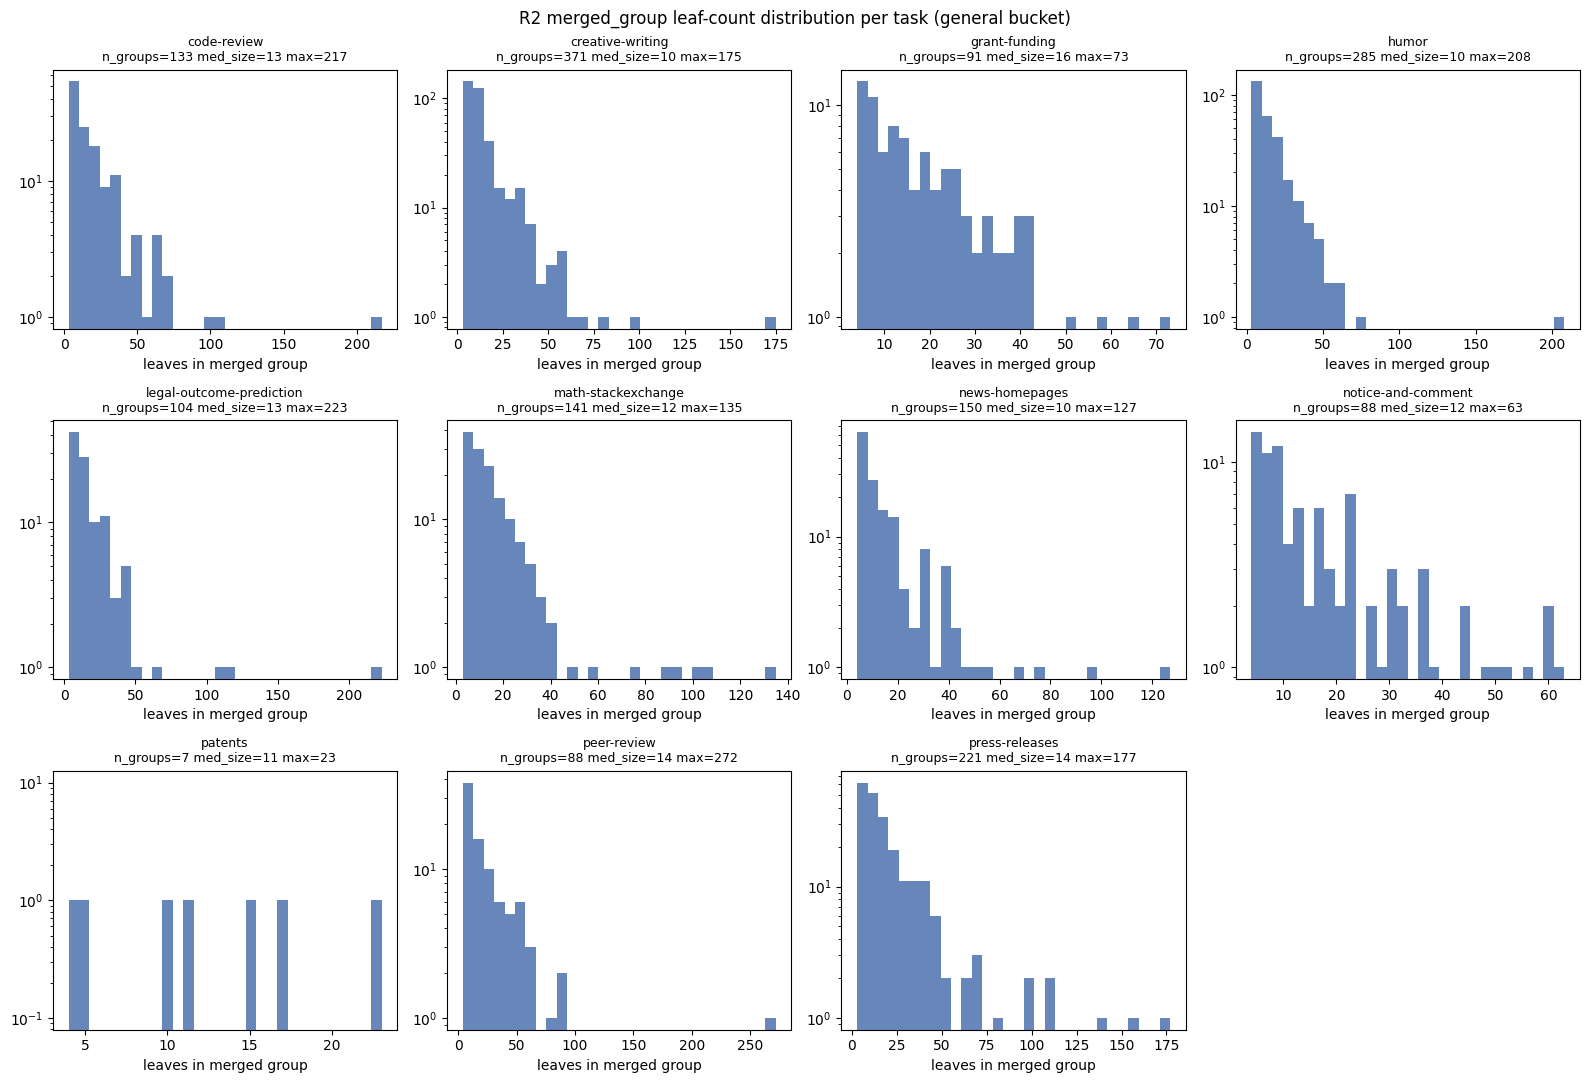

In [7]:
def _r2_merged_groups(task, bucket):
    p = HIER / f"{task}_{bucket}_r2_expanded.json"
    if not p.exists():
        return []
    return json.loads(p.read_text()).get("merged_groups", [])


def _r2_grandparents(task, bucket):
    p = HIER / f"{task}_{bucket}_r2_expanded.json"
    if not p.exists():
        return []
    return json.loads(p.read_text()).get("grandparents", [])


fig, axes = plt.subplots(3, 4, figsize=(16, 11), sharex=False)
for ax, task in zip(axes.flat, TASKS):
    mg = _r2_merged_groups(task, "general")
    sizes = [m.get("total_leaf_rubrics", 0) for m in mg]
    if not sizes:
        ax.set_title(task)
        ax.set_visible(False)
        continue
    ax.hist(sizes, bins=30, color="#4C72B0", alpha=0.85)
    ax.set_title(f"{task}\nn_groups={len(mg)} med_size={int(np.median(sizes))} max={max(sizes)}", fontsize=9)
    ax.set_xlabel("leaves in merged group")
    ax.set_yscale("log")
for ax in axes.flat[len(TASKS):]:
    ax.set_visible(False)
fig.suptitle("R2 merged_group leaf-count distribution per task (general bucket)")
plt.tight_layout()
plt.show()

## 4. Top concepts per task (R2 merged_groups, general bucket)

A first qualitative pass — what evaluation categories emerged at scale?

In [8]:
TOP_N = 15
for task in TASKS:
    mg = sorted(_r2_merged_groups(task, "general"), key=lambda m: -m.get("total_leaf_rubrics", 0))
    if not mg:
        continue
    print(f"\n=== {task}  (top {min(TOP_N, len(mg))} of {len(mg)} merged groups) ===")
    for m in mg[:TOP_N]:
        n = m.get("total_leaf_rubrics", 0)
        nm = (m.get("merged_name") or "")[:80]
        print(f"  [{n:>3}]  {nm}")


=== code-review  (top 15 of 133 merged groups) ===
  [217]  Simplicity (KISS/YAGNI) and complexity management
  [105]  Intention‑revealing naming and conventions
  [100]  Appropriate use of established design patterns
  [ 71]  Change description clarity, completeness, and rationale (commits, PRs, changelog
  [ 68]  Testing strategy and layering (pyramid)
  [ 67]  Accessibility and inclusive design practices
  [ 64]  Code smells: identification and targeted refactoring
  [ 63]  Conventions adherence (local and ecosystem)
  [ 61]  Code style guide adherence and consistency
  [ 56]  Small, cohesive functions and decomposition
  [ 51]  Control-flow clarity and low cognitive complexity
  [ 50]  Documentation quality, structure, and audience fit
  [ 50]  Naming clarity, consistency, and conventions
  [ 48]  Performance optimization discipline
  [ 44]  Design patterns literacy and contextual application

=== creative-writing  (top 15 of 371 merged groups) ===
  [175]  Show–Tell Balance and D

## 5. R3 grandparents per task — higher-level categories

In [9]:
def _r3_grandparents(task, bucket):
    p = HIER / f"{task}_{bucket}_r3_expanded.json"
    if not p.exists():
        return []
    return json.loads(p.read_text()).get("grandparents", [])


for task in TASKS:
    gp = sorted(_r3_grandparents(task, "general"), key=lambda g: -g.get("n_children", 0))
    if not gp:
        continue
    print(f"\n=== {task}  R3 grandparents (top {min(TOP_N, len(gp))} of {len(gp)}) ===")
    for g in gp[:TOP_N]:
        nc = g.get("n_children", 0)
        nl = g.get("total_leaf_rubrics", 0)
        nm = (g.get("grandparent_name") or "")[:80]
        print(f"  [{nc:>3} children, {nl:>4} leaves]  {nm}")


=== code-review  R3 grandparents (top 15 of 23) ===
  [  8 children,   67 leaves]  Modularity, cohesion, and coupling control
  [  7 children,  239 leaves]  Change submission quality and reviewability
  [  5 children,   64 leaves]  Formatting standards and tooling
  [  5 children,   77 leaves]  Error handling quality and robustness
  [  4 children,  127 leaves]  Refactoring discipline and smell remediation
  [  4 children,  149 leaves]  Testing strategy and layering
  [  4 children,   26 leaves]  Behavior‑centric testing and specification
  [  4 children,   89 leaves]  Public API usability and documentation
  [  4 children,  242 leaves]  Simplicity, explicitness, and avoidance of over‑engineering
  [  4 children,   81 leaves]  Performance engineering discipline
  [  4 children,   60 leaves]  Distributed resilience and reliability engineering
  [  4 children,   68 leaves]  Observability and diagnostics
  [  4 children,  104 leaves]  Accessibility and inclusive design
  [  4 children,  

## 6. Coverage / stranded children — what got dropped during refinement?

Refinement removes children that don't fit their assigned parent (misfits).
A high stranded fraction in a task hints that R1 parents were noisy and many
children were forcibly grouped.

In [10]:
strand_rows = []
for task in TASKS:
    for bucket in BUCKETS:
        p = HIER / f"{task}_{bucket}_r1_refined_stranded.json"
        if not p.exists():
            continue
        sd = json.loads(p.read_text())
        n_stranded = sd.get("n_stranded", 0)
        # find corresponding refined-input children count
        cell_row = cells_df[(cells_df.task == task) & (cells_df.bucket == bucket)]
        if cell_row.empty:
            continue
        n_children = int(cell_row.iloc[0]["r1_children"])
        strand_rows.append({
            "task": task,
            "bucket": bucket,
            "n_stranded": n_stranded,
            "n_kept_children": n_children,
            "stranded_pct": 100 * n_stranded / max(1, n_stranded + n_children),
        })
strand_df = pd.DataFrame(strand_rows)
print("Stranded children per cell (children dropped from parents as misfits):\n")
print(strand_df.sort_values(["task", "bucket"]).to_string(index=False))

Stranded children per cell (children dropped from parents as misfits):

                    task         bucket  n_stranded  n_kept_children  stranded_pct
             code-review        general         179             2255      7.354150
             code-review hyper_specific          66              859      7.135135
             code-review       specific         313             7909      3.806860
        creative-writing        general         495             5180      8.722467
           grant-funding        general         112             1094      9.286899
           grant-funding hyper_specific          15              199      7.009346
           grant-funding       specific          68             1041      6.131650
                   humor        general         480             4307     10.027157
                   humor hyper_specific           6              136      4.225352
                   humor       specific         158             1912      7.632850
legal-outcome-p

## 7. Compression ratio R1-leaves → R2-merged_groups, visual

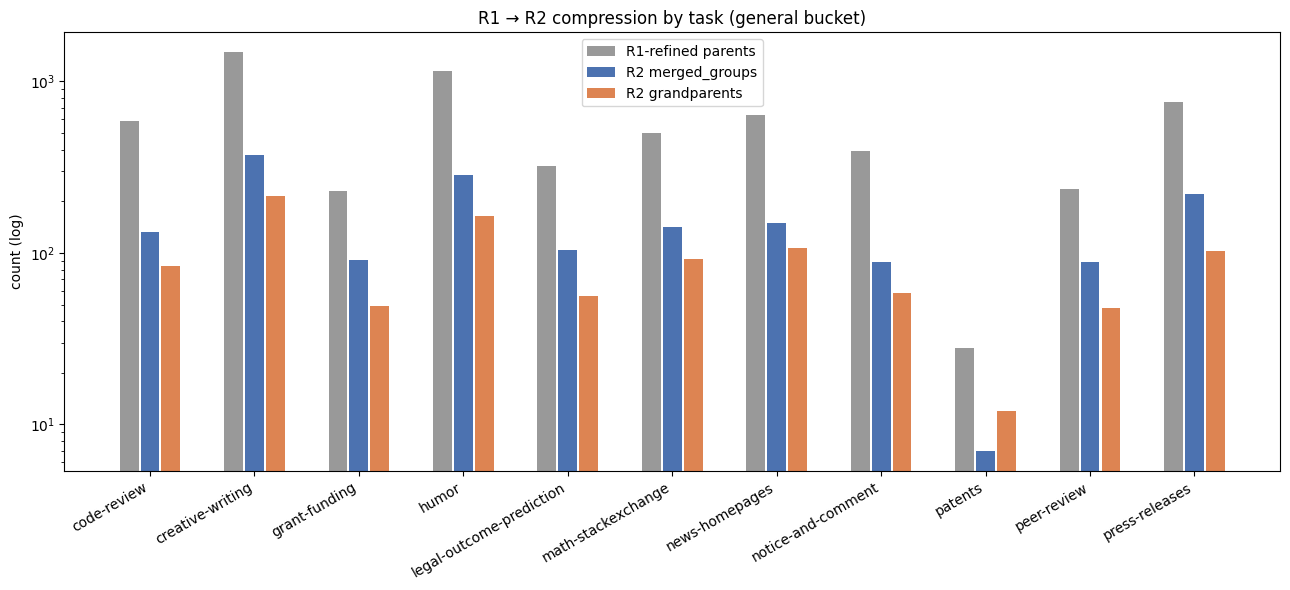

In [11]:
fig, ax = plt.subplots(figsize=(13, 6))
g_cells = cells_df[cells_df.bucket == "general"].sort_values("task")
x = np.arange(len(g_cells))
ax.bar(x - 0.2, g_cells["r1_parents"], width=0.18, label="R1-refined parents", color="#999999")
ax.bar(x,        g_cells["r2_merged_groups"], width=0.18, label="R2 merged_groups", color="#4C72B0")
ax.bar(x + 0.2,  g_cells["r2_grandparents"], width=0.18, label="R2 grandparents", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(g_cells["task"], rotation=30, ha="right")
ax.set_yscale("log")
ax.set_ylabel("count (log)")
ax.set_title("R1 → R2 compression by task (general bucket)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. STUB — Phase 2: diffuseness per merged_group

Plan: embed each R1 child (medoid name+description) under a merged_group
with text-embedding-3-small; compute cosine-spread (1 - mean intra-group
cosine to centroid). High spread = the LLM merged things that aren't actually
very similar = "thick" group.

In [12]:
# def diffuseness_per_merged_group(task, bucket):
#     mg = _r2_merged_groups(task, bucket)
#     # ... embed each m["all_leaves"]'s medoid → np.array
#     # ... centroid = mean; spread = mean(1 - cosine(member, centroid))
#     pass

## 9. STUB — Phase 3: source-origin distribution per merged_group

Needs joining R1 leaf rubrics back to `pages_df.source_file` (from
explore_rubrics.py) to label each leaf's origin type. Then for each R2
merged_group: count leaves per source type.

In [13]:
# def source_origin_per_merged_group(task, bucket):
#     mg = _r2_merged_groups(task, bucket)
#     # each m["all_leaves"] is a list of rubric dicts with page_id back-references
#     # join to pages_df on page_id to get orientation/wave_tag/source_dir
#     pass

## 10. STUB — Phase 4: cross-task concept overlap

Embed every R2 merged_group name across all 11 tasks together; cluster the
embeddings; groups appearing in ≥3 tasks are "universal" concepts; groups
in 1 task are domain-specific.

In [14]:
# def cross_task_overlap():
#     all_groups = []  # (task, merged_name, merged_description, total_leaf_rubrics)
#     for task in TASKS:
#         for m in _r2_merged_groups(task, "general"):
#             all_groups.append((task, m["merged_name"], m["merged_description"], m.get("total_leaf_rubrics", 0)))
#     # embed merged_name + ": " + merged_description with text-embedding-3-small
#     # cluster via complete-linkage at threshold 0.75
#     # report clusters with >=3 distinct task labels
#     pass